In [7]:
%run "/Users/hayeonchung/Downloads/CNN/get_cnn_data_v2.ipynb"

<>:8: SyntaxWarning: invalid escape sequence '\c'
/var/folders/6y/d5yr54g90_nbghlfwx83ldb40000gn/T/ipykernel_6655/2802897405.py:8: SyntaxWarning: invalid escape sequence '\c'
  return x - 273.15, "$^{\circ}$C"


In [3]:
import numpy as np
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models


/opt/miniconda3/envs/ds6001/lib/python3.13/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [9]:
x_data, y_data = get_cnn_tensors(
    model_list=model_list,
    scenario="ssp126",
    data_path=data_path,
    var_idx="all",          
    use_anomaly=True,  
    stat="mean",
    st_early=2015, end_early=2024,
    st_late=2055, end_late=2064
)

print(x_data.shape, y_data.shape)


Variable: ['tas', 'tasmax', 'tasmin', 'pr', 'psl', 'sfcWind', 'mrsos'] | Stat: mean | Anomaly: True
Processing Model: CNRM_ESM2-1


/var/folders/6y/d5yr54g90_nbghlfwx83ldb40000gn/T/ipykernel_6655/3559321759.py:96: RuntimeWarning: Mean of empty slice
  v_mean = np.nanmean(v_data[:, b_start:b_end, :, :], axis=1)
/var/folders/6y/d5yr54g90_nbghlfwx83ldb40000gn/T/ipykernel_6655/3559321759.py:120: RuntimeWarning: Mean of empty slice
  yearly_val = calc_func(annual_slice, axis=0)


Processing Model: MIROC6
Processing Model: MPI-ESM1-2-LR
Processing Model: MRI-ESM2-0
Processing Model: UKESM1-0-LL
(500, 7, 144, 73) (500, 1)


In [ ]:
X = np.transpose(x_data, (0, 2, 3, 1))  # (N, lat, lon, 1)
y = y_data.astype(np.float32)           # (N, 1)

print("X:", X.shape, "y:", y.shape) # FIX 2: SHOULD BE (500,144,73,7) and (500,1)

X: (500, 144, 73, 7) y: (500, 1)


Reason for transposing: From get_cnn_tensors, my raw tensor shape was (1000, 1, 144, 73). This means 1000 samples, 1 channel, 144 latitude, 73 longitude. However, TensorFlow expects (1000 ,144, 73, 1) format. This is ensuring that my CNN sees [lat,lon] as the 2D image. 

In [11]:
# 1) test = 50
X_rem, X_test, y_rem, y_test = train_test_split(
    X, y,
    test_size=50,
    random_state=42,
    stratify=y
)

# 2) val = 50 (from remaining 450)
X_train, X_val, y_train, y_val = train_test_split(
    X_rem, y_rem,
    test_size=50,
    random_state=42,
    stratify=y_rem
)

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)
print("Class balance:", y_train.mean(), y_val.mean(), y_test.mean())


Train: (400, 144, 73, 7) Val: (50, 144, 73, 7) Test: (50, 144, 73, 7)
Class balance: 0.5 0.5 0.5


In [12]:
def nan_report(name, arr):
    frac = np.isnan(arr).mean()
    print(f"{name}: any NaNs? {np.isnan(arr).any()} | frac NaNs = {frac:.6f}")

nan_report("X_train", X_train)
nan_report("X_val", X_val)
nan_report("X_test", X_test)


X_train: any NaNs? False | frac NaNs = 0.000000
X_val: any NaNs? False | frac NaNs = 0.000000
X_test: any NaNs? False | frac NaNs = 0.000000


## Medium Architecture (~92k parameters)

In [15]:
lat, lon = X_train.shape[1], X_train.shape[2]

model = models.Sequential([
    layers.Input(shape=(lat, lon, 7)), # FIX #1: SHOULD BE A 7 (lat,lon,7)

    # CNN block (64 filters) with two convs, then pool
    layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
    layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2)),  # (lat/2, lon/2, 64)

    # CNN block 32 kernels (conv + pool)
    layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
    layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2)),  # (lat/4, lon/4, 32) 

    # CNN block 16 kernels (conv only)
    layers.Conv2D(16, (3, 3), padding="same", activation="relu"),
    layers.Conv2D(16, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(8, (3, 3), padding="same", activation="relu"),
    layers.Conv2D(8, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),             
    layers.Dense(50, activation="relu"),
    layers.Dense(10, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 144, 73, 64)    │         4,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 144, 73, 64)    │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 72, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 72, 36, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 72, 36, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 36, 18, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 36, 18, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 36, 18, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 18, 9, 16)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 18, 9, 8)       │         1,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 18, 9, 8)       │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 9, 4, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 288)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 50)             │        14,450 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           510 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 92,395 (360.92 KB)

 Trainable params: 92,395 (360.92 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
    verbose=2
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=18,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 174ms/step - accuracy: 0.6150 - loss: 110110432.0000 - val_accuracy: 0.7600 - val_loss: 0.5194
Epoch 2/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 179ms/step - accuracy: 0.7625 - loss: 0.5374 - val_accuracy: 0.8000 - val_loss: 0.4920
Epoch 3/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 177ms/step - accuracy: 0.7800 - loss: 0.5275 - val_accuracy: 0.8200 - val_loss: 0.4852
Epoch 4/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 168ms/step - accuracy: 0.7800 - loss: 0.5222 - val_accuracy: 0.8200 - val_loss: 0.4815
Epoch 5/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 165ms/step - accuracy: 0.7800 - loss: 0.5183 - val_accuracy: 0.8200 - val_loss: 0.4783
Epoch 6/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 166ms/step - accuracy: 0.7750 - loss: 0.5148 - val_accuracy: 0.8200 - val_loss: 0.4753
Epoch 7/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 167ms/step - accuracy: 0.7750 - loss: 0.5117 - val_accuracy: 0.8200 - val_loss: 0.4723
Epoch 8/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 168ms/step - accuracy: 0.7750 - loss: 0.5082 - 

In [17]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print("Test accuracy:", test_acc)

Test accuracy: 0.9800000190734863


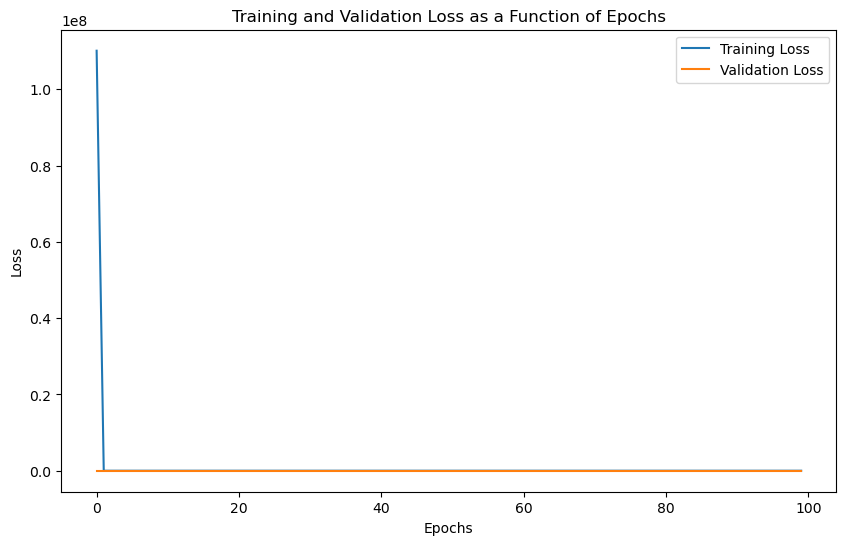

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training and Validation Loss as a Function of Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()


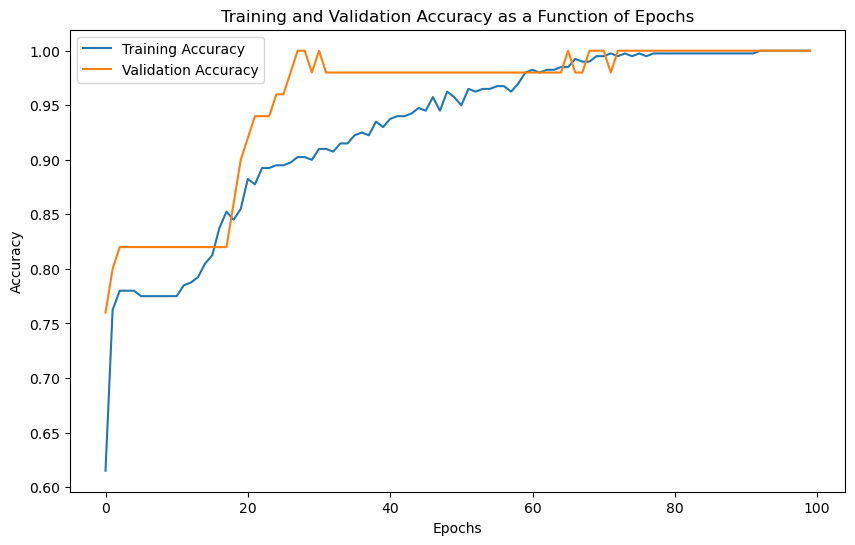

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training and Validation Accuracy as a Function of Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


# Adjusting Model

### Large architecture (~200k parameters)

In [23]:
lat, lon = X_train.shape[1], X_train.shape[2]

model = models.Sequential([
    layers.Input(shape=(lat, lon, 7)), 

    # CNN block (64 filters) with two convs, then pool
    layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
    layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2)),  # (lat/2, lon/2, 64)

    # CNN block 32 kernels (conv + pool)
    layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
    layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2)),  # (lat/4, lon/4, 32) 

    # CNN block 16 kernels (conv only)
    layers.Conv2D(16, (3, 3), padding="same", activation="relu"),
    layers.Conv2D(16, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),             
    layers.Dense(50, activation="relu"),
    layers.Dense(10, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

model.summary()


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_26 (Conv2D)              │ (None, 144, 73, 64)    │         4,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 144, 73, 64)    │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 72, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 72, 36, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 72, 36, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 36, 18, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_30 (Conv2D)              │ (None, 36, 18, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 36, 18, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 18, 9, 16)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 2592)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 50)             │       129,650 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │           510 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 205,851 (804.11 KB)

 Trainable params: 205,851 (804.11 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
    verbose=2
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=18,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 174ms/step - accuracy: 0.6050 - loss: 143435936.0000 - val_accuracy: 0.8200 - val_loss: 0.4830
Epoch 2/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 174ms/step - accuracy: 0.8050 - loss: 0.5106 - val_accuracy: 0.9600 - val_loss: 0.4682
Epoch 3/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 168ms/step - accuracy: 0.8925 - loss: 0.4934 - val_accuracy: 0.9800 - val_loss: 0.4498
Epoch 4/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 170ms/step - accuracy: 0.8975 - loss: 0.4715 - val_accuracy: 0.9600 - val_loss: 0.4239
Epoch 5/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 174ms/step - accuracy: 0.8750 - loss: 0.4396 - val_accuracy: 0.9400 - val_loss: 0.3827
Epoch 6/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 170ms/step - accuracy: 0.8825 - loss: 0.3996 - val_accuracy: 0.9400 - val_loss: 0.3394
Epoch 7/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 172ms/step - accuracy: 0.8750 - loss: 0.3551 - val_accuracy: 0.9800 - val_loss: 0.2948
Epoch 8/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 178ms/step - accuracy: 0.9025 - loss: 0.3118 - 

In [25]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print("Test accuracy:", test_acc)

Test accuracy: 1.0


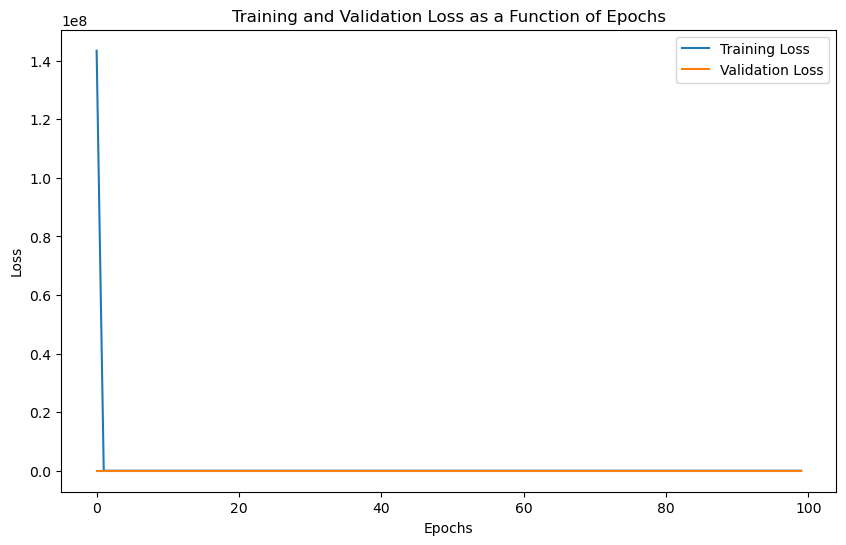

In [26]:
plt.figure(figsize=(10,6))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training and Validation Loss as a Function of Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()


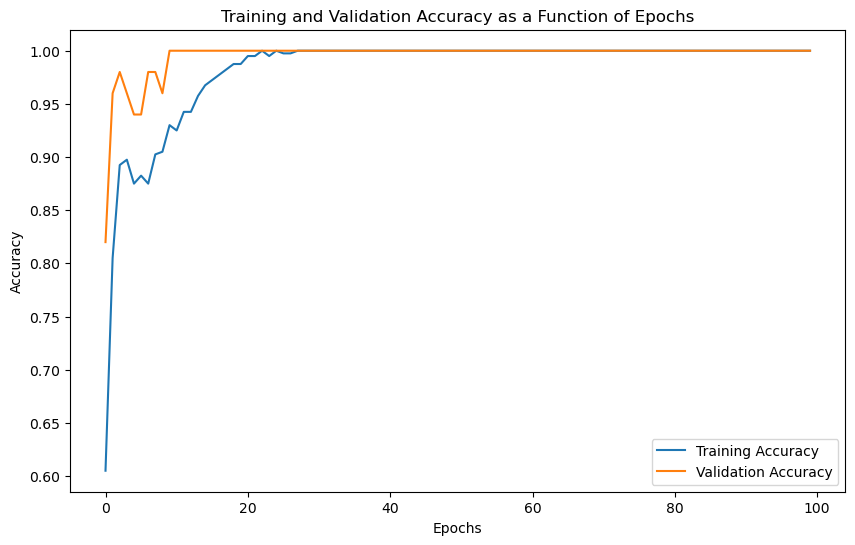

In [27]:
plt.figure(figsize=(10,6))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training and Validation Accuracy as a Function of Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


### Small architecture (~30k parameters)

In [ ]:
lat, lon = X_train.shape[1], X_train.shape[2]

small_model = models.Sequential([
    layers.Input(shape=(lat, lon, 7)),

    layers.Conv2D(32, (3,3), padding="same", activation="relu"),
    layers.Conv2D(32, (3,3), padding="same", activation="relu"),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), padding="same", activation="relu"),
    layers.MaxPooling2D((2,2)),

    layers.GlobalAveragePooling2D(),
    layers.Dense(32, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

small_model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_32 (Conv2D)              │ (None, 144, 73, 32)    │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_33 (Conv2D)              │ (None, 144, 73, 32)    │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 72, 36, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_34 (Conv2D)              │ (None, 72, 36, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 36, 18, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,905 (124.63 KB)

 Trainable params: 31,905 (124.63 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
small_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
    verbose=2
)

history = small_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=18,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - accuracy: 0.4800 - loss: 4411699200.0000 - val_accuracy: 0.5000 - val_loss: 0.5011
Epoch 2/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - accuracy: 0.5000 - loss: 0.5437 - val_accuracy: 0.5000 - val_loss: 0.4969
Epoch 3/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - accuracy: 0.6975 - loss: 0.5402 - val_accuracy: 0.9000 - val_loss: 0.4937
Epoch 4/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - accuracy: 0.8650 - loss: 0.5377 - val_accuracy: 0.8800 - val_loss: 0.4910
Epoch 5/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - accuracy: 0.8300 - loss: 0.5356 - val_accuracy: 0.8400 - val_loss: 0.4887
Epoch 6/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - accuracy: 0.8175 - loss: 0.5336 - val_accuracy: 0.8200 - val_loss: 0.4867
Epoch 7/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - accuracy: 0.8100 - loss: 0.5318 - val_accuracy: 0.8200 - val_loss: 0.4847
Epoch 8/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - accuracy: 0.8075 - loss: 0.5301 - val_acc

In [30]:
test_loss, test_acc = small_model.evaluate(X_test, y_test, verbose=0)
print("Test accuracy:", test_acc)

Test accuracy: 0.8799999952316284


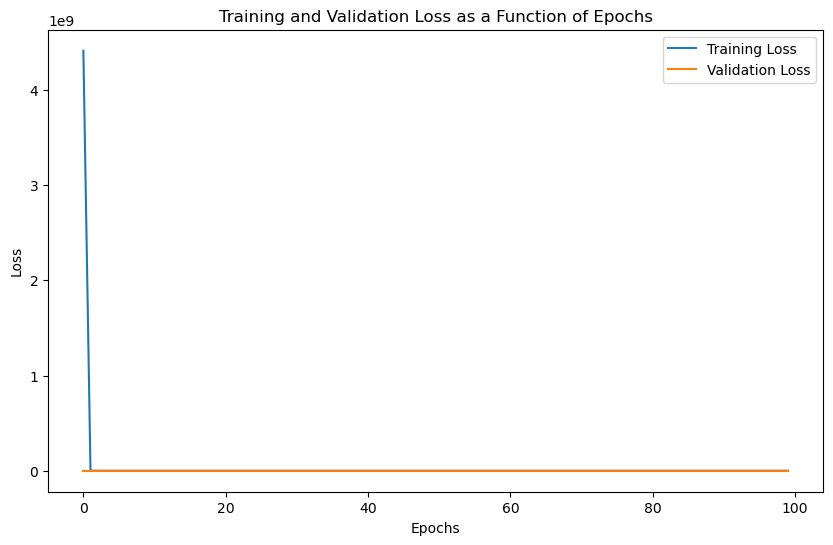

In [31]:
plt.figure(figsize=(10,6))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training and Validation Loss as a Function of Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()


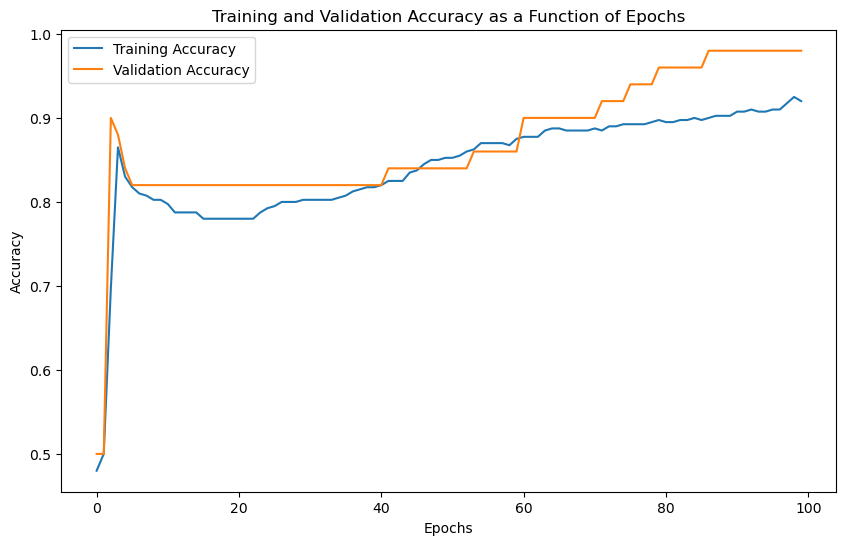

In [32]:
plt.figure(figsize=(10,6))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training and Validation Accuracy as a Function of Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()
